In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed

from model import SocialGPModel
from rewards import (
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    _min_max,
    generate_env,
)

In [17]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Setup: Environment and Conditions

In [18]:
# Build correlation matrix
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])
n_children = corr_matrix.shape[0] - 1
grid_size = 11

In [19]:
# Define test conditions
alpha_test_conditions = {
    "standard_kalman": {
        "label": "Standard Kalman\n(α ∝ v_pred)",
        "params": {
            "rho_update_rule": "rho_kalman",
            "rho": rho_zero,
            "model_type": "SG-ICM",
            "rho_update_init": 0.0,
            "rho_update_kwargs": {"learning_rate_type": "kalman_standard"},
        }
    },
    "inverted_kalman": {
        "label": "Inverted Kalman\n(α ∝ 1/v_pred)",
        "params": {
            "rho_update_rule": "rho_kalman",  # Current implementation
            "rho": rho_zero,
            "model_type": "SG-ICM",
            "rho_update_init": 0.0,
        }
    },
    "fixed_baseline": {
        "label": "Fixed α=0.3",
        "params": {
            "rho_update_rule": "rho_kalman",
            "rho": rho_zero,
            "model_type": "SG-ICM",
            "rho_update_init": 0.0,
            "rho_update_kwargs": {"learning_rate_type": "fixed", "learning_rate_value": 0.3},
        }
    },
    "calibrated": {
        "label": "Calibrated\n(no learning)",
        "params": {
            "rho_update_rule": None,
            "rho": rho_true,
            "model_type": "SG-ICM",
        }
    },
}

In [20]:
def get_agent0_rho(model):
    """Extract rho vector from the main agent (Agent 0)"""
    agent = model.grid.agents[0]
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    if agent._rho_updater is None:
        return np.array(agent.rho, dtype=float)
    return agent._rho_updater.get_rho_vector(neighbors)


def get_agent0_alpha_history(model):
    """Extract alpha values from the main agent's rho updater"""
    agent = model.grid.agents[0]
    if agent._rho_updater is None or not hasattr(agent._rho_updater, '_last_update_info'):
        return None
    
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    alphas = []
    for neighbor_id in neighbors:
        if neighbor_id in agent._rho_updater._last_update_info:
            alphas.append(agent._rho_updater._last_update_info[neighbor_id]['alpha'])
        else:
            alphas.append(np.nan)
    return np.array(alphas)


def get_agent0_prediction_variance(model):
    """Extract prediction variance from the main agent's last update"""
    agent = model.grid.agents[0]
    if agent._rho_updater is None or not hasattr(agent._rho_updater, '_last_update_info'):
        return None
    
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    variances = []
    for neighbor_id in neighbors:
        if neighbor_id in agent._rho_updater._last_update_info:
            variances.append(agent._rho_updater._last_update_info[neighbor_id]['v_pred'])
        else:
            variances.append(np.nan)
    return np.array(variances)


def get_agent0_z_history(model):
    """Extract z values (correlation evidence) from main agent"""
    agent = model.grid.agents[0]
    if agent._rho_updater is None or not hasattr(agent._rho_updater, '_last_update_info'):
        return None
    
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    z_values = []
    for neighbor_id in neighbors:
        if neighbor_id in agent._rho_updater._last_update_info:
            z_values.append(agent._rho_updater._last_update_info[neighbor_id]['z_t'])
        else:
            z_values.append(np.nan)
    return np.array(z_values)


def get_agent0_components(model):
    """Extract m_tilde and r_tilde (standardized components)"""
    agent = model.grid.agents[0]
    if agent._rho_updater is None or not hasattr(agent._rho_updater, '_last_update_info'):
        return None, None
    
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    m_tildes = []
    r_tildes = []
    for neighbor_id in neighbors:
        if neighbor_id in agent._rho_updater._last_update_info:
            m_tildes.append(agent._rho_updater._last_update_info[neighbor_id]['m_tilde'])
            r_tildes.append(agent._rho_updater._last_update_info[neighbor_id]['r_tilde'])
        else:
            m_tildes.append(np.nan)
            r_tildes.append(np.nan)
    return np.array(m_tildes), np.array(r_tildes)


def get_agent0_raw_values(model):
    """Extract raw m_pred and r_obs (before standardization)"""
    agent = model.grid.agents[0]
    if agent._rho_updater is None or not hasattr(agent._rho_updater, '_last_update_info'):
        return None, None
    
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    m_preds = []
    r_obs = []
    for neighbor_id in neighbors:
        if neighbor_id in agent._rho_updater._last_update_info:
            m_preds.append(agent._rho_updater._last_update_info[neighbor_id]['m_pred'])
            r_obs.append(agent._rho_updater._last_update_info[neighbor_id]['r_obs'])
        else:
            m_preds.append(np.nan)
            r_obs.append(np.nan)
    return np.array(m_preds), np.array(r_obs)


def get_agent0_running_variance(model):
    """Extract the running variances from stats"""
    agent = model.grid.agents[0]
    if agent._rho_updater is None:
        return None, None
    
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    var_m = []
    var_r = []
    for neighbor_id in neighbors:
        if neighbor_id in agent._rho_updater.stats_m:
            var_m.append(agent._rho_updater.stats_m[neighbor_id].var)
            var_r.append(agent._rho_updater.stats_r[neighbor_id].var)
        else:
            var_m.append(np.nan)
            var_r.append(np.nan)
    return np.array(var_m), np.array(var_r)


def run_alpha_test_condition(condition_name, condition_cfg, parent, child_maps, n_steps, seed=0):
    """Run one condition and collect comprehensive diagnostics"""
    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        rho_update_sigma_zeta=0.1,
        rho_update_basis="full",
        tau_sampling=True,
        beta_sampling=True,
        length_scale_sampling=True,
        seed=seed,
        **condition_cfg["params"]
    )

    # Collect all diagnostics
    rho_history = []
    alpha_history = []
    variance_history = []
    z_history = []
    m_tilde_history = []
    r_tilde_history = []
    m_pred_history = []
    r_obs_history = []
    var_m_history = []
    var_r_history = []
    
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))
        alpha_history.append(get_agent0_alpha_history(m))
        variance_history.append(get_agent0_prediction_variance(m))
        z_history.append(get_agent0_z_history(m))
        
        m_tilde, r_tilde = get_agent0_components(m)
        m_tilde_history.append(m_tilde)
        r_tilde_history.append(r_tilde)
        
        m_pred, r_obs = get_agent0_raw_values(m)
        m_pred_history.append(m_pred)
        r_obs_history.append(r_obs)
        
        var_m, var_r = get_agent0_running_variance(m)
        var_m_history.append(var_m)
        var_r_history.append(var_r)

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["seed"] = seed
    
    return {
        "df": df,
        "rho_history": np.array(rho_history),
        "alpha_history": alpha_history,
        "variance_history": variance_history,
        "z_history": z_history,
        "m_tilde_history": m_tilde_history,
        "r_tilde_history": r_tilde_history,
        "m_pred_history": m_pred_history,
        "r_obs_history": r_obs_history,
        "var_m_history": var_m_history,
        "var_r_history": var_r_history,
    }

In [ ]:
def process_one_seed_alpha_test(env_seed):
    """Process one seed for alpha testing with full diagnostics"""
    local_results = []
    local_histories = []

    parent, child_maps = generate_env(env_seed, np.array([1, 0.6, 0.0, -0.6]), corr_matrix, grid_size=grid_size)

    for condition_name, condition_cfg in alpha_test_conditions.items():
        result = run_alpha_test_condition(
            condition_name,
            condition_cfg,
            parent,
            child_maps,
            n_steps=15,
            seed=env_seed,
        )
        local_results.append(result["df"])
        local_histories.append({
            "condition": condition_name,
            "condition_label": condition_cfg["label"],
            "seed": env_seed,
            "rho_history": result["rho_history"],
            "alpha_history": result["alpha_history"],
            "variance_history": result["variance_history"],
            "z_history": result["z_history"],
            "m_tilde_history": result["m_tilde_history"],
            "r_tilde_history": result["r_tilde_history"],
            "m_pred_history": result["m_pred_history"],
            "r_obs_history": result["r_obs_history"],
            "var_m_history": result["var_m_history"],
            "var_r_history": result["var_r_history"],
        })
    
    return local_results, local_histories

In [ ]:
n_envs = 1000
n_steps = 15

parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_one_seed_alpha_test)(seed) for seed in tqdm(range(n_envs))
)

alpha_results = []
alpha_histories = []

for seed_dfs, seed_histories in parallel_outputs:
    alpha_results.extend(seed_dfs)
    alpha_histories.extend(seed_histories)

alpha_results_df = pd.concat(alpha_results, ignore_index=True)
alpha_results_df.head()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:43<00:00, 23.05it/s]


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,seed
0,1,1,"(9, 9)",0.522229,0.522229,SG-ICM,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,standard_kalman,Standard Kalman\n(α ∝ v_pred),0
1,1,2,"(5, 4)",0.864346,0.864346,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,standard_kalman,Standard Kalman\n(α ∝ v_pred),0
2,1,3,"(9, 8)",1.000175,1.000175,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,standard_kalman,Standard Kalman\n(α ∝ v_pred),0
3,1,4,"(3, 10)",0.169582,0.169582,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,standard_kalman,Standard Kalman\n(α ∝ v_pred),0
4,2,1,"(10, 5)",0.089970,0.612199,SG-ICM,0.01244,4.787198,4.123106,4.123106,4.123106,5.621207,5.621207,3.162278,standard_kalman,Standard Kalman\n(α ∝ v_pred),0


/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_49201/3167099708.py:30: RuntimeWarning: Mean of empty slice
  mean_alpha = np.nanmean(peer_alphas, axis=0)
/Users/leeliang/Desktop/0HMC/CogSci2026/Spatial-MAB-ABM/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


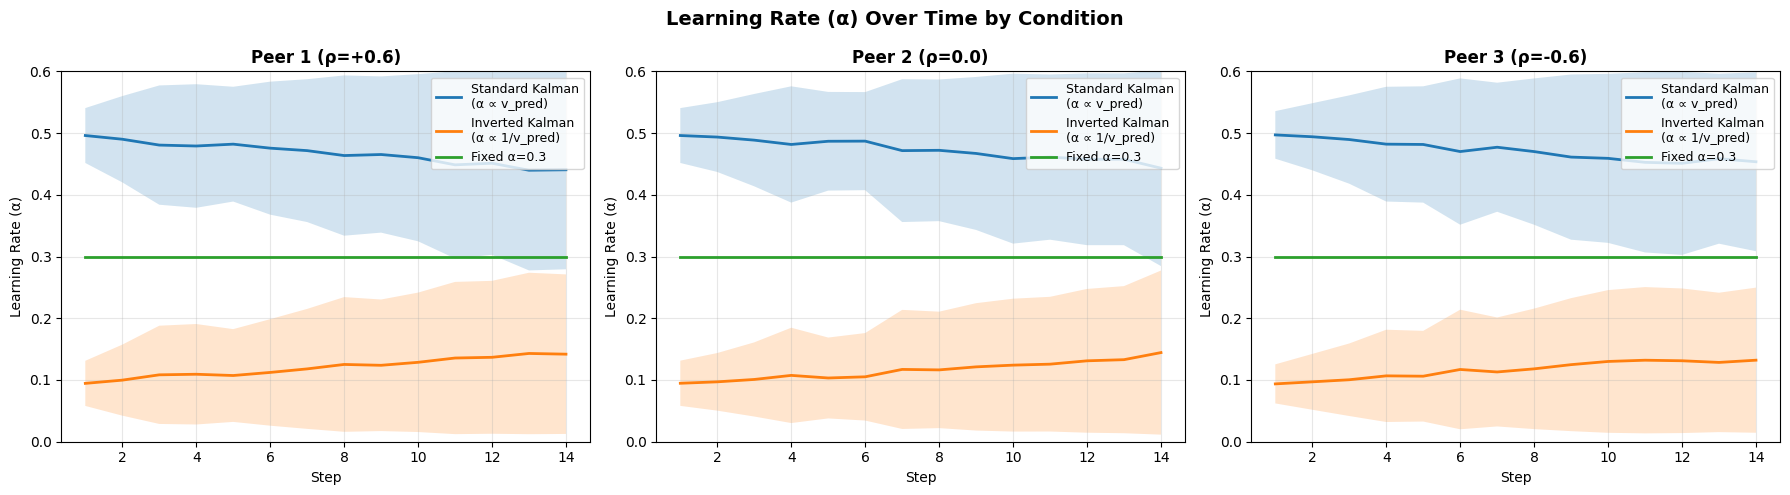

In [23]:
def plot_alpha_over_time(histories, exclude_conditions=None):
    """Plot how alpha changes over trials for different conditions"""
    exclude_conditions = exclude_conditions or ["calibrated"]
    
    # Group by condition
    condition_data = {}
    for entry in histories:
        cond = entry["condition"]
        if cond in exclude_conditions:
            continue
        if cond not in condition_data:
            condition_data[cond] = {"label": entry["condition_label"], "alphas": []}
        condition_data[cond]["alphas"].append(entry["alpha_history"])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    peer_names = ["Peer 1 (ρ=+0.6)", "Peer 2 (ρ=0.0)", "Peer 3 (ρ=-0.6)"]
    
    for peer_idx, (ax, peer_name) in enumerate(zip(axes, peer_names)):
        for cond, data in condition_data.items():
            # Collect alpha values for this peer across all seeds
            peer_alphas = []
            for seed_alphas in data["alphas"]:
                # Each seed_alphas is a list of arrays (one per step)
                peer_alpha_series = [step_alphas[peer_idx] if step_alphas is not None and peer_idx < len(step_alphas) else np.nan 
                                    for step_alphas in seed_alphas]
                peer_alphas.append(peer_alpha_series)
            
            # Convert to array and compute mean
            peer_alphas = np.array(peer_alphas)  # Shape: (n_seeds, n_steps)
            mean_alpha = np.nanmean(peer_alphas, axis=0)
            std_alpha = np.nanstd(peer_alphas, axis=0)
            
            steps = np.arange(len(mean_alpha))
            ax.plot(steps, mean_alpha, label=data["label"], linewidth=2)
            ax.fill_between(steps, mean_alpha - std_alpha, mean_alpha + std_alpha, alpha=0.2)
        
        ax.set_title(peer_name, fontsize=12, fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Learning Rate (α)")
        ax.set_ylim(0, 0.6)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
    
    plt.suptitle("Learning Rate (α) Over Time by Condition", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_alpha_over_time(alpha_histories)

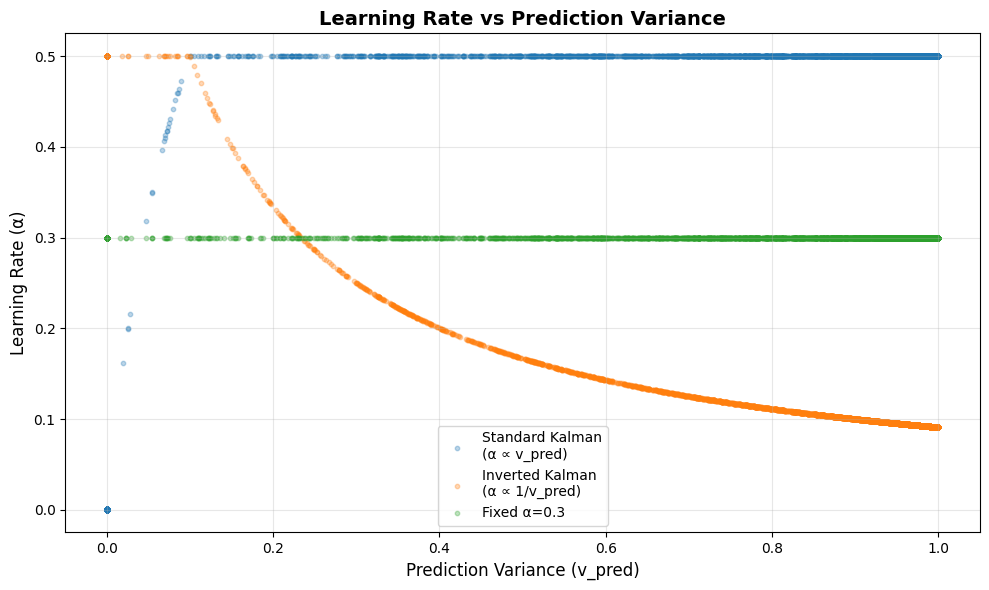

In [24]:
def plot_alpha_vs_variance(histories, exclude_conditions=None):
    """Scatter plot: alpha vs prediction variance to show relationship"""
    exclude_conditions = exclude_conditions or ["calibrated"]
    
    plot_data = []
    for entry in histories:
        if entry["condition"] in exclude_conditions:
            continue
        
        alphas = entry["alpha_history"]
        variances = entry["variance_history"]
        
        for step_idx, (step_alphas, step_vars) in enumerate(zip(alphas, variances)):
            if step_alphas is None or step_vars is None:
                continue
            for peer_idx, (alpha, var) in enumerate(zip(step_alphas, step_vars)):
                if np.isfinite(alpha) and np.isfinite(var):
                    plot_data.append({
                        "condition": entry["condition_label"],
                        "alpha": alpha,
                        "variance": var,
                        "peer": peer_idx,
                        "step": step_idx,
                    })
    
    plot_df = pd.DataFrame(plot_data)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for condition in plot_df["condition"].unique():
        cond_data = plot_df[plot_df["condition"] == condition]
        ax.scatter(cond_data["variance"], cond_data["alpha"], label=condition, alpha=0.3, s=10)
    
    ax.set_xlabel("Prediction Variance (v_pred)", fontsize=12)
    ax.set_ylabel("Learning Rate (α)", fontsize=12)
    ax.set_title("Learning Rate vs Prediction Variance", fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return plot_df

alpha_variance_df = plot_alpha_vs_variance(alpha_histories)

### Visualization: Rho Learning Trajectories

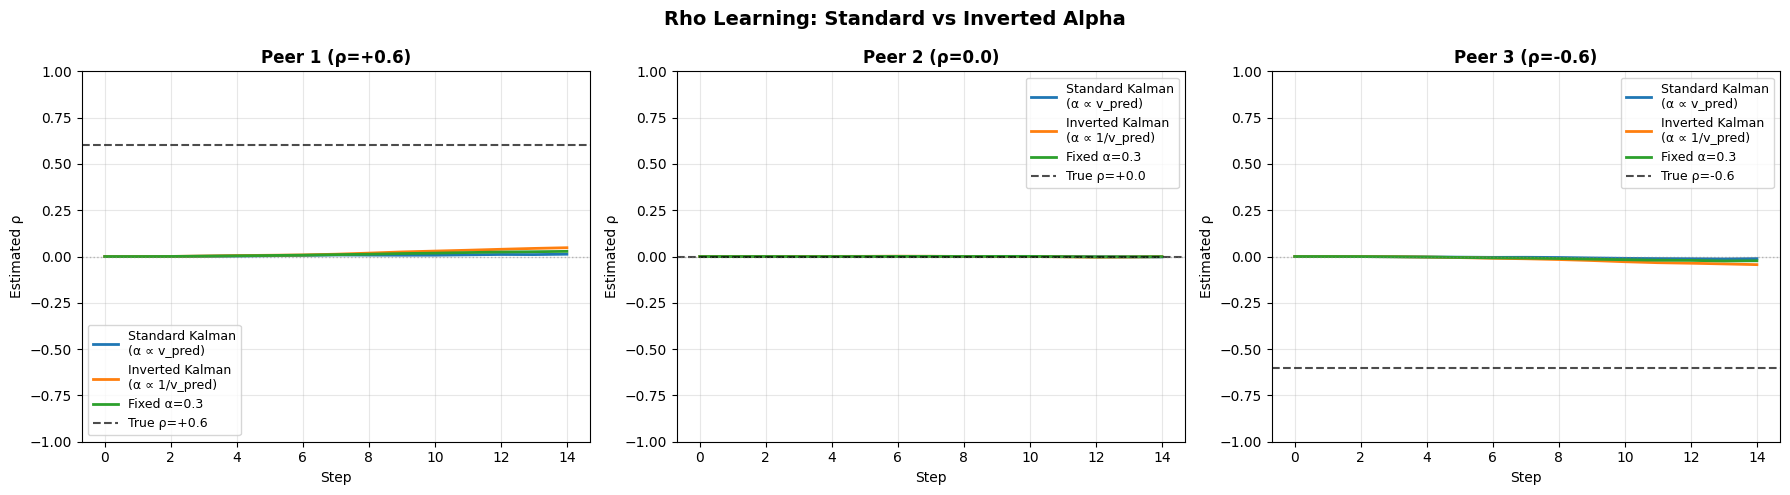

In [25]:
def plot_rho_trajectories(histories, true_rho_values, exclude_conditions=None):
    """Plot rho learning over time for different alpha strategies"""
    exclude_conditions = exclude_conditions or ["calibrated"]
    
    condition_data = {}
    for entry in histories:
        cond = entry["condition"]
        if cond in exclude_conditions:
            continue
        if cond not in condition_data:
            condition_data[cond] = {"label": entry["condition_label"], "histories": []}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    peer_names = ["Peer 1 (ρ=+0.6)", "Peer 2 (ρ=0.0)", "Peer 3 (ρ=-0.6)"]
    
    for peer_idx, (ax, peer_name, true_val) in enumerate(zip(axes, peer_names, true_rho_values)):
        for cond, data in condition_data.items():
            histories = np.stack(data["histories"], axis=0)  # (n_seeds, n_steps, n_agents)
            mean_traj = np.mean(histories, axis=0)
            rho_over_time = mean_traj[:, peer_idx + 1]  # +1 to skip self-correlation
            ax.plot(rho_over_time, label=data["label"], linewidth=2)
        
        ax.axhline(true_val, linestyle='--', color='black', alpha=0.7, linewidth=1.5, 
                   label=f'True ρ={true_val:+.1f}')
        ax.axhline(0, linestyle=':', color='gray', alpha=0.5, linewidth=1)
        
        ax.set_title(peer_name, fontsize=12, fontweight='bold')
        ax.set_xlabel("Step")
        ax.set_ylabel("Estimated ρ")
        ax.set_ylim(-1.0, 1.0)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
    
    plt.suptitle("Rho Learning: Standard vs Inverted Alpha", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

true_rho_peers = rho_true[1:]
plot_rho_trajectories(alpha_histories, true_rho_peers)

In [26]:
def compute_alpha_test_summary(histories, results_df, true_rho_values):
    """Compute summary statistics for alpha test conditions"""
    summary = []
    
    condition_data = {}
    for entry in histories:
        cond = entry["condition"]
        if cond not in condition_data:
            condition_data[cond] = {"label": entry["condition_label"], "histories": []}
        condition_data[cond]["histories"].append(entry["rho_history"])
    
    for cond, data in condition_data.items():
        histories = np.stack(data["histories"], axis=0)
        final_estimates = histories[:, -1, 1:]  # Last step, exclude self-correlation
        
        # Compute MAE
        final_mae = np.abs(final_estimates - true_rho_values).mean()
        peer1_mae = np.abs(final_estimates[:, 0] - true_rho_values[0]).mean()
        peer2_mae = np.abs(final_estimates[:, 1] - true_rho_values[1]).mean()
        peer3_mae = np.abs(final_estimates[:, 2] - true_rho_values[2]).mean()
        
        # Get final rewards
        cond_df = results_df[results_df["condition"] == cond]
        sg_agent = cond_df[cond_df["model_type"] == "SG-ICM"]
        final_step = sg_agent.groupby("seed")["Step"].transform('max')
        final_rewards = sg_agent[sg_agent["Step"] == final_step]["cumulative_reward"]
        
        summary.append({
            "condition": cond,
            "label": data["label"],
            "final_mae": final_mae,
            "peer1_mae (ρ=+0.6)": peer1_mae,
            "peer2_mae (ρ=0.0)": peer2_mae,
            "peer3_mae (ρ=-0.6)": peer3_mae,
            "mean_reward": final_rewards.mean(),
            "std_reward": final_rewards.std(),
        })
    
    return pd.DataFrame(summary)

alpha_summary = compute_alpha_test_summary(alpha_histories, alpha_results_df, true_rho_peers)
print(alpha_summary.to_string(index=False))

      condition                           label  final_mae  peer1_mae (ρ=+0.6)  peer2_mae (ρ=0.0)  peer3_mae (ρ=-0.6)  mean_reward  std_reward
standard_kalman   Standard Kalman\n(α ∝ v_pred)   0.398431            0.587395           0.019334            0.588563     9.296065    2.216446
inverted_kalman Inverted Kalman\n(α ∝ 1/v_pred)   0.386023            0.552428           0.049485            0.556156     9.318456    2.173579
 fixed_baseline                     Fixed α=0.3   0.392583            0.572093           0.028571            0.577086     9.332814    2.186530
     calibrated       Calibrated\n(no learning)   0.000000            0.000000           0.000000            0.000000     9.995435    2.040351
